In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [15]:
df = pd.read_csv('canadian_immegration_data.csv')

###Understand the dataset

Let's first check the structure of the data.


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 39 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    195 non-null    object
 1   Continent  195 non-null    object
 2   Region     195 non-null    object
 3   DevName    195 non-null    object
 4   1980       195 non-null    int64 
 5   1981       195 non-null    int64 
 6   1982       195 non-null    int64 
 7   1983       195 non-null    int64 
 8   1984       195 non-null    int64 
 9   1985       195 non-null    int64 
 10  1986       195 non-null    int64 
 11  1987       195 non-null    int64 
 12  1988       195 non-null    int64 
 13  1989       195 non-null    int64 
 14  1990       195 non-null    int64 
 15  1991       195 non-null    int64 
 16  1992       195 non-null    int64 
 17  1993       195 non-null    int64 
 18  1994       195 non-null    int64 
 19  1995       195 non-null    int64 
 20  1996       195 non-null    int64

In [17]:
df.describe()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,508.394872,566.989744,534.723077,387.435897,376.497436,358.861538,441.271795,691.133333,714.389744,843.241026,...,1320.292308,1266.958974,1191.820513,1246.394872,1275.733333,1420.287179,1262.533333,1313.958974,1320.702564,32867.451282
std,1949.588546,2152.643752,1866.997511,1204.333597,1198.246371,1079.309600,1225.576630,2109.205607,2443.606788,2555.048874,...,4425.957828,3926.717747,3443.542409,3694.573544,3829.630424,4462.946328,4030.084313,4247.555161,4237.951988,91785.498686
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,1.000000,1.000000,...,28.500000,25.000000,31.000000,31.000000,36.000000,40.500000,37.500000,42.500000,45.000000,952.000000
50%,13.000000,10.000000,11.000000,12.000000,13.000000,17.000000,18.000000,26.000000,34.000000,44.000000,...,210.000000,218.000000,198.000000,205.000000,214.000000,211.000000,179.000000,233.000000,213.000000,5018.000000
75%,251.500000,295.500000,275.000000,173.000000,181.000000,197.000000,254.000000,434.000000,409.000000,508.500000,...,832.000000,842.000000,899.000000,934.500000,888.000000,932.000000,772.000000,783.000000,796.000000,22239.500000
max,22045.000000,24796.000000,20620.000000,10015.000000,10170.000000,9564.000000,9470.000000,21337.000000,27359.000000,23795.000000,...,42584.000000,33848.000000,28742.000000,30037.000000,29622.000000,38617.000000,36765.000000,34315.000000,34129.000000,691904.000000


###Check if a counrty appears multiple times due to typos.

In [18]:
print(len(df['Country'].unique()))

195


#Data cleaning, handle missing values

In [19]:
print(df.isnull().sum())

Country      0
Continent    0
Region       0
DevName      0
1980         0
1981         0
1982         0
1983         0
1984         0
1985         0
1986         0
1987         0
1988         0
1989         0
1990         0
1991         0
1992         0
1993         0
1994         0
1995         0
1996         0
1997         0
1998         0
1999         0
2000         0
2001         0
2002         0
2003         0
2004         0
2005         0
2006         0
2007         0
2008         0
2009         0
2010         0
2011         0
2012         0
2013         0
Total        0
dtype: int64


<Axes: >

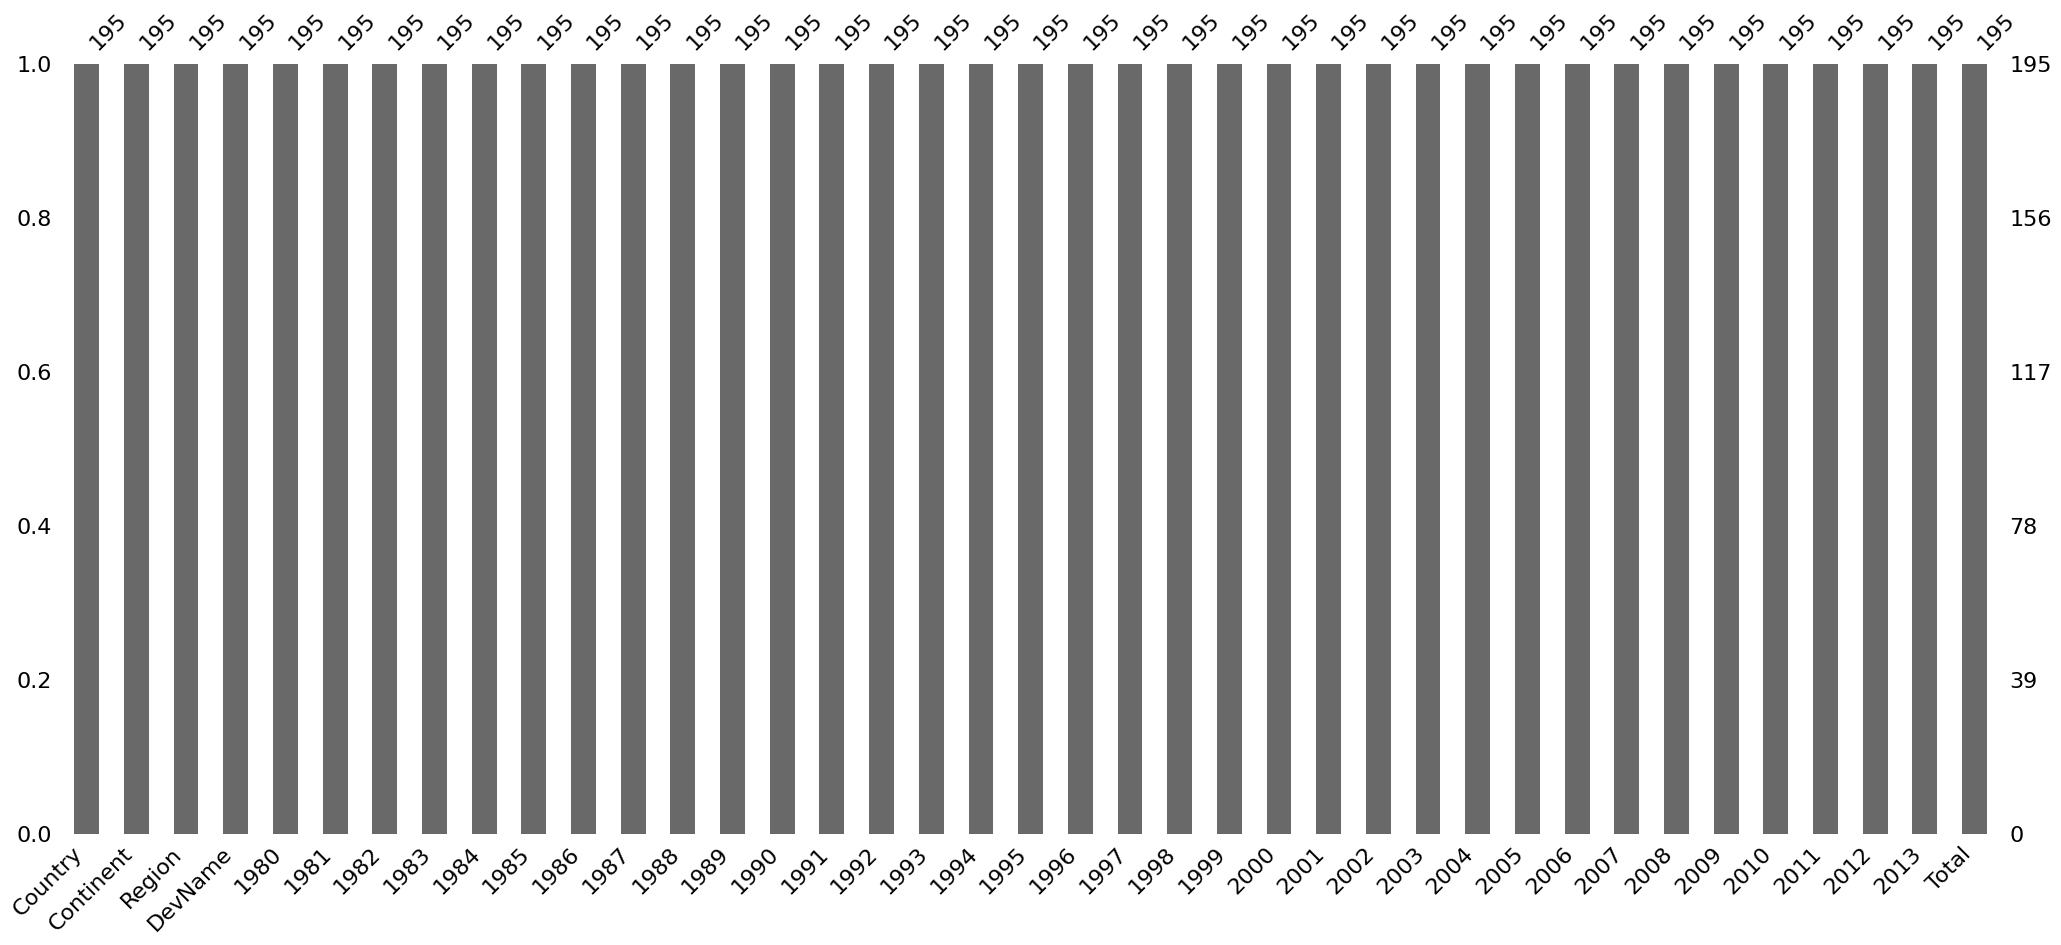

In [20]:
msno.bar(df)

<Axes: >

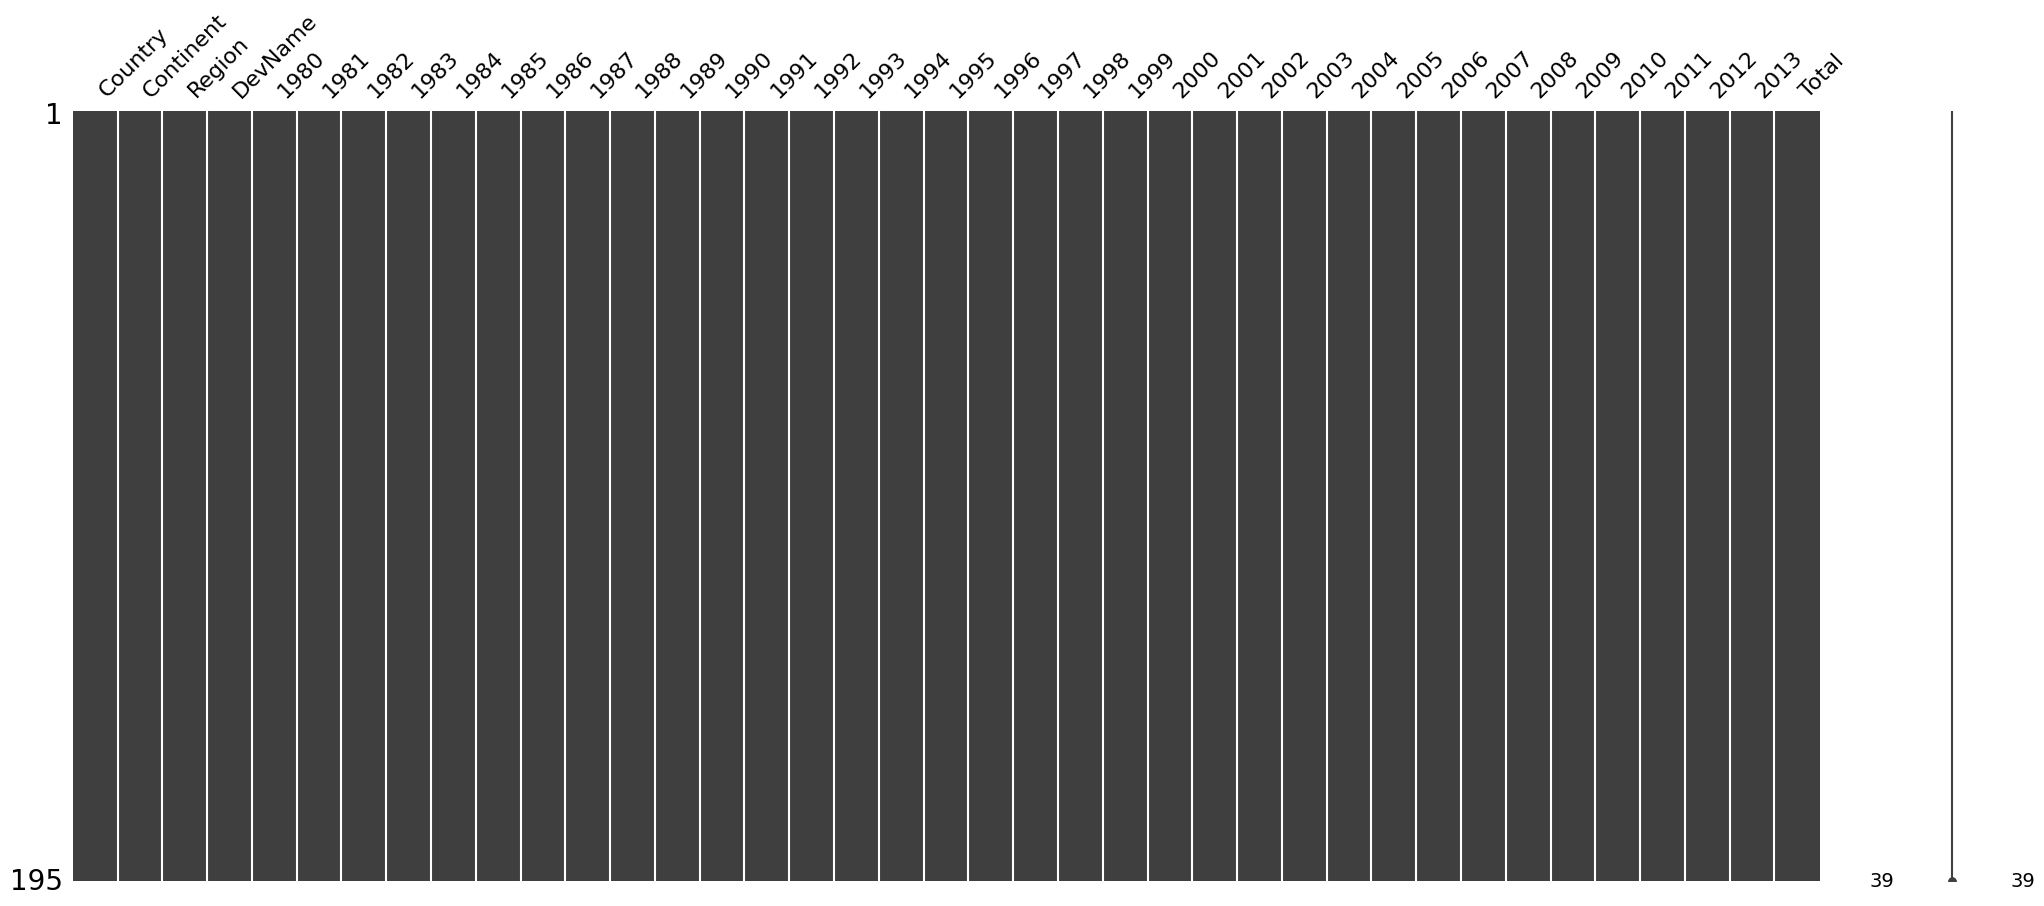

In [21]:
msno.matrix(df)

###Great there is no missing values

#Let's explore Trends Over Time

##Let's plot total immigration over the years to identify trends

In [22]:
year_columns = [col for col in df.columns if col.isdigit() and 1980<= int(col) <= 2013]

Total Canadian immigration by year from 1980 to 2013

<ipython-input-23-64d360489ec6>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = immigration_df, x = "Year", y = "Total_Immigrants", palette = "Blues" )


<Figure size 1200x600 with 0 Axes>

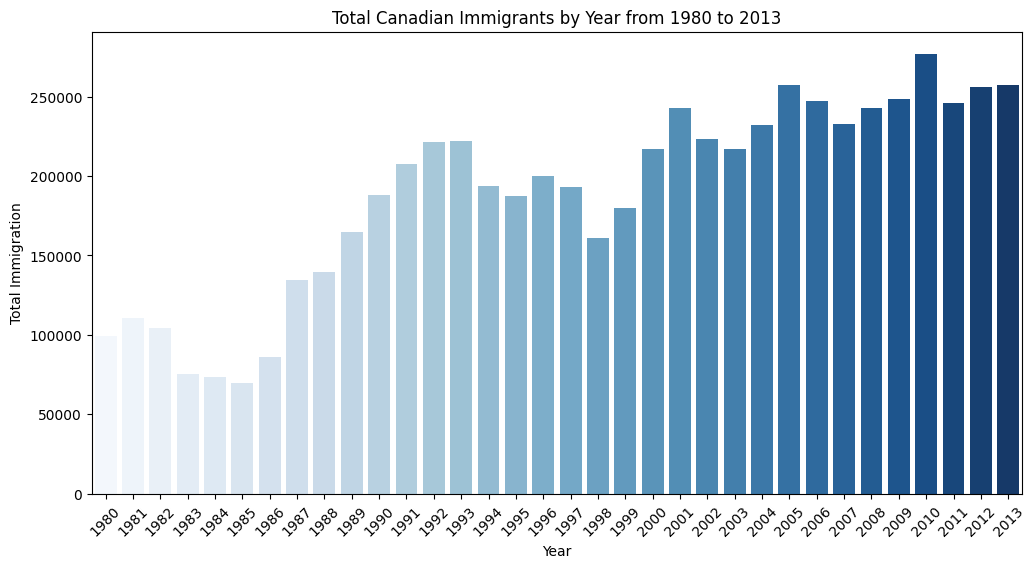

In [23]:
plt.figure(figsize = (12, 6))

total_immigration = df[year_columns].sum()


# Convert to a DataFrame for visualization
immigration_df = pd.DataFrame({"Year": year_columns, "Total_Immigrants": total_immigration.values})

# Convert "Year" to integer for correct sorting in plots
immigration_df["Year"] = immigration_df["Year"].astype(int)

#Create bar plot

plt.figure(figsize = (12, 6))
sns.barplot(data = immigration_df, x = "Year", y = "Total_Immigrants", palette = "Blues" )
plt.title("Total Canadian Immigrants by Year from 1980 to 2013")
plt.xticks(rotation = 45)
plt.xlabel("Year")
plt.ylabel("Total Immigration")
plt.show()


We see that the year in which the immigration was the gratest is 2010.

Let's see yearly trend plotting the immigration trend for the top 5 countries

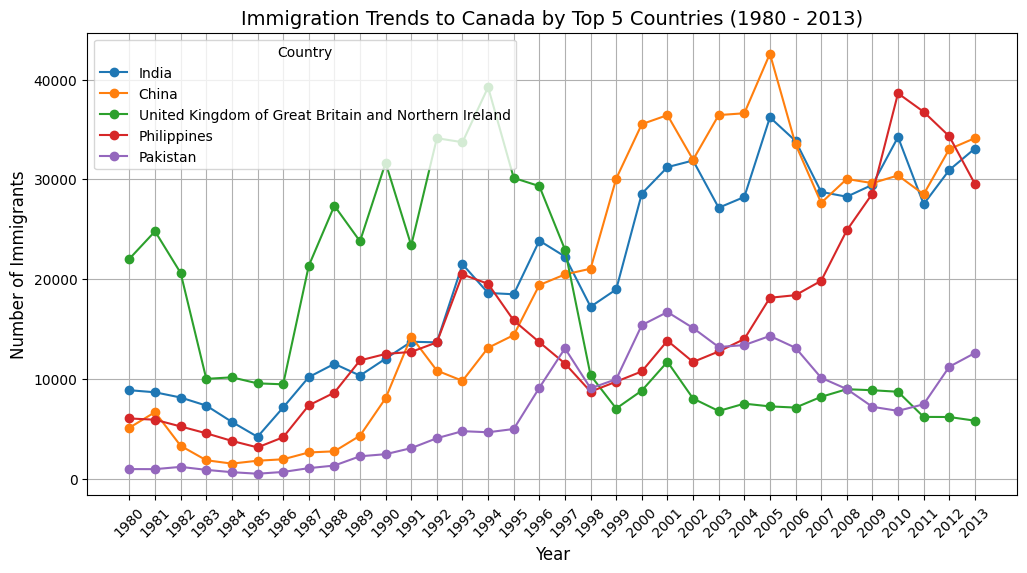

In [24]:
# Example: Plot the immigration trend for the top 5 countries (replace with actual countries in your dataset)
top_countries = df.groupby('Country')[year_columns].sum().sum(axis=1).nlargest(5).index

plt.figure(figsize=(12, 6))
for country in top_countries:
    country_data = df[df['Country'] == country][year_columns].sum()
    plt.plot(country_data.index, country_data.values, marker='o', label=country)

# Formatting
plt.title('Immigration Trends to Canada by Top 5 Countries (1980 - 2013)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Immigrants', fontsize=12)
plt.legend(title='Country')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [25]:
df['Country'] = df['Country'].replace("United Kingdom of Great Britain and Northern Ireland", "UK and Northern Ireland")
df['Country'] = df['Country'].replace("United States of America", "USA")

##Immigration to Canada in 2010 top 10 countries

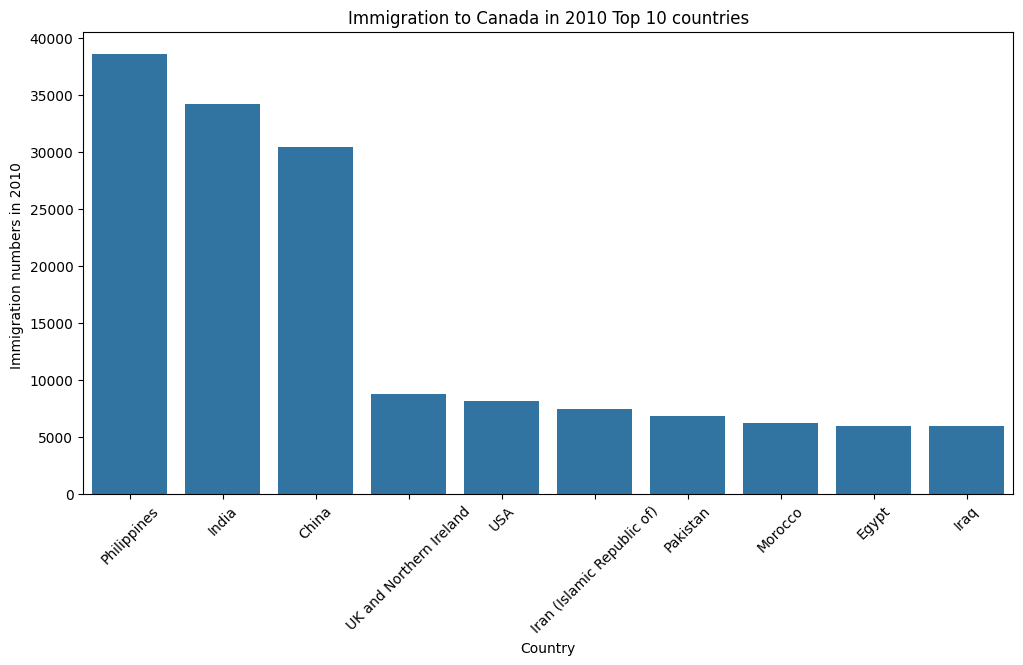

In [26]:
#Extract the immigration data for 2010
immigration_2010 = df[['Country', '2010']]

immigration_2010_sorted = immigration_2010.sort_values(by = '2010', ascending = False)

#Create a bar plot for the immigration numbers for 2010
plt.figure(figsize = (12,6))
sns.barplot(data = immigration_2010_sorted.head(10), x = 'Country', y = '2010' )

plt.xticks(rotation = 45)
plt.xlabel('Country')
plt.ylabel('Immigration numbers in 2010 ')
plt.title('Immigration to Canada in 2010 Top 10 countries')
plt.show()

In [27]:
df['Country'] = df['Country'].replace("United Kingdom of Great Britain and Northern Ireland", "UK and Northern Ireland")

##Immigration trends to Canada by Continent

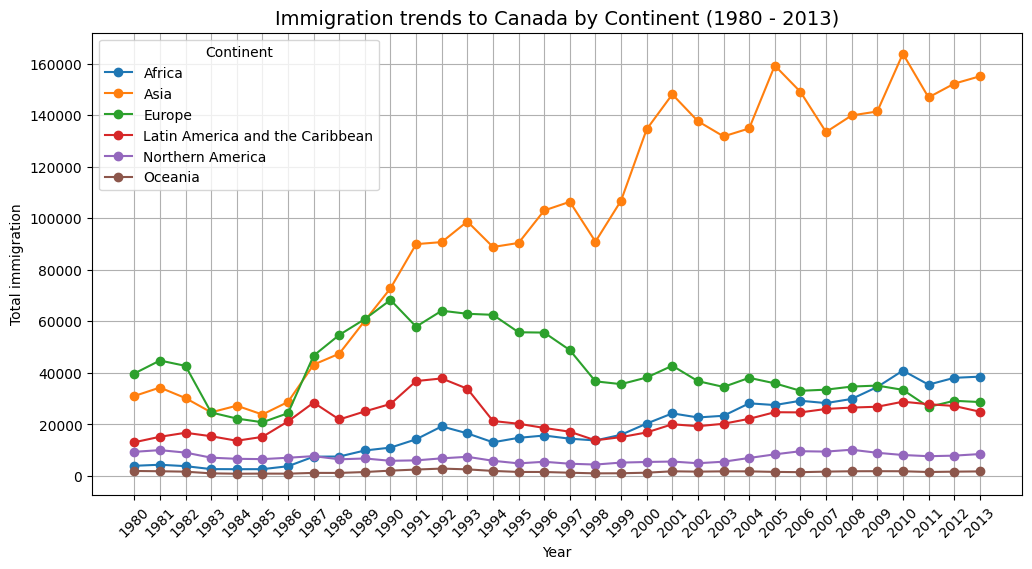

In [28]:
continent_immigration = df.groupby('Continent')[year_columns].sum().T


plt.figure(figsize = (12,6))
for continent in continent_immigration.columns:
  plt.plot(continent_immigration.index, continent_immigration[continent], marker = 'o', label = continent)

plt.title("Immigration trends to Canada by Continent (1980 - 2013)" ,fontsize = 14)
plt.xlabel("Year")
plt.ylabel("Total immigration")
plt.legend(title = "Continent")
plt.grid(True)
plt.xticks(rotation = 45)
plt.show()

##Campare immigration by Region

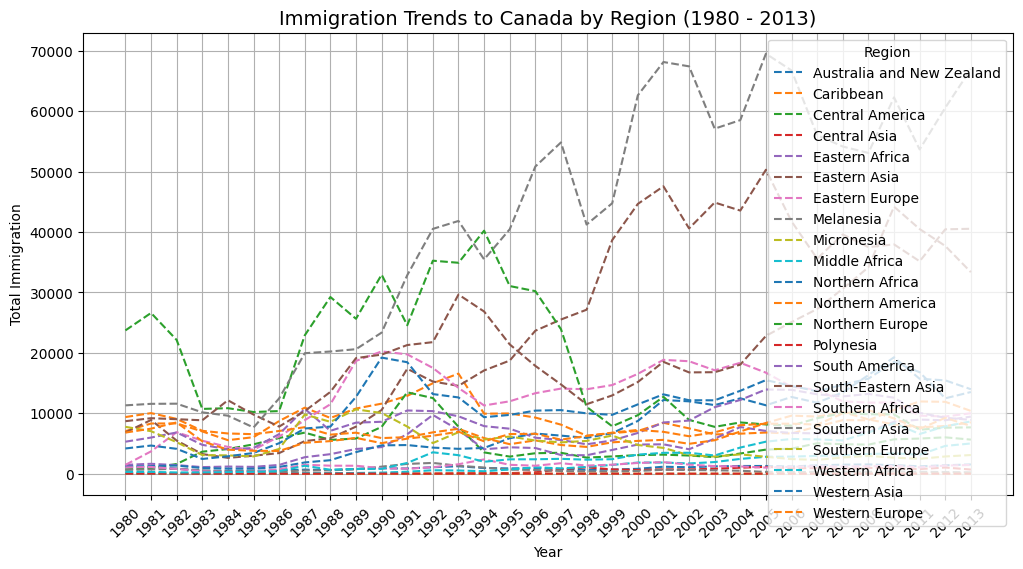

In [29]:
region_immigration = df.groupby('Region')[year_columns].sum().T

plt.figure(figsize = (12,6))
for region in region_immigration.columns:
  plt.plot(region_immigration.index, region_immigration[region], linestyle = '--', label = region)
plt.title("Immigration Trends to Canada by Region (1980 - 2013)", fontsize = 14)
plt.xlabel("Year")
plt.ylabel("Total Immigration")
plt.legend(title = "Region")
plt.grid(True)
plt.xticks(rotation = 45)
plt.show()

Let's focus on the Top 5 regions with the highest immigration instead.

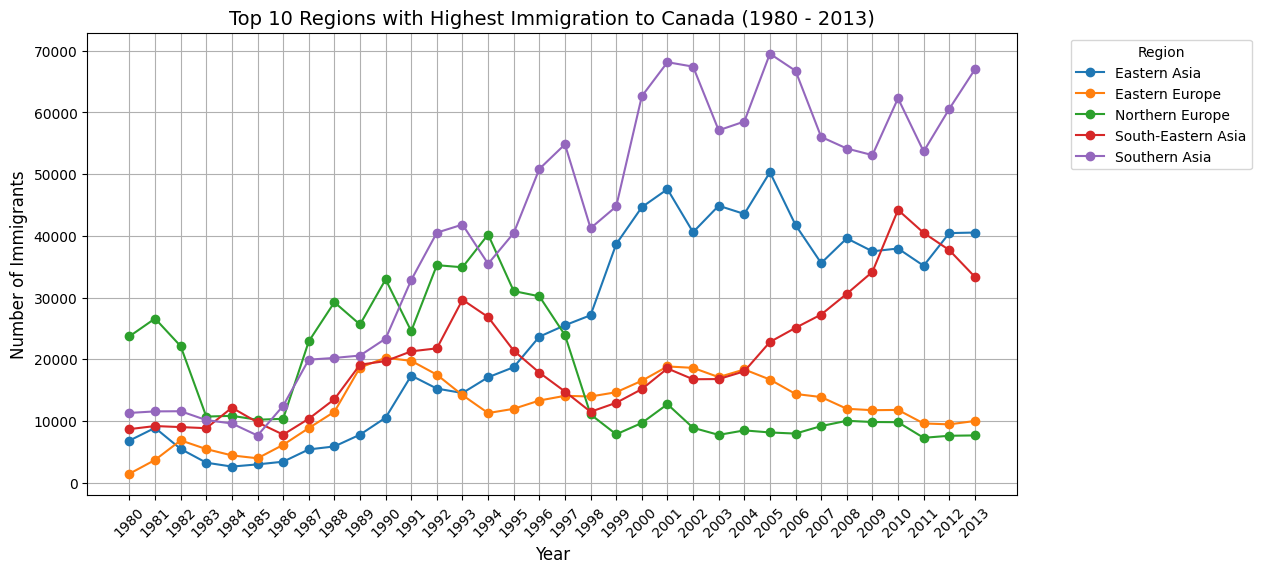

In [30]:
# Group by Region and calculate total immigration across all years
total_immigration_by_region = df.groupby('Region')[year_columns].sum().sum(axis=1)

# Get the Top 10 regions with the highest total immigration
top_5_regions = total_immigration_by_region.nlargest(5).index

# Filter only those top 5 regions
top_regions_immigration = df[df['Region'].isin(top_5_regions)].groupby('Region')[year_columns].sum().T

# Plot the trends
plt.figure(figsize=(12, 6))
for region in top_regions_immigration.columns:
    plt.plot(top_regions_immigration.index, top_regions_immigration[region], marker='o', label=region)

# Formatting
plt.title('Top 10 Regions with Highest Immigration to Canada (1980 - 2013)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Immigrants', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Bar charts for top contributing countries

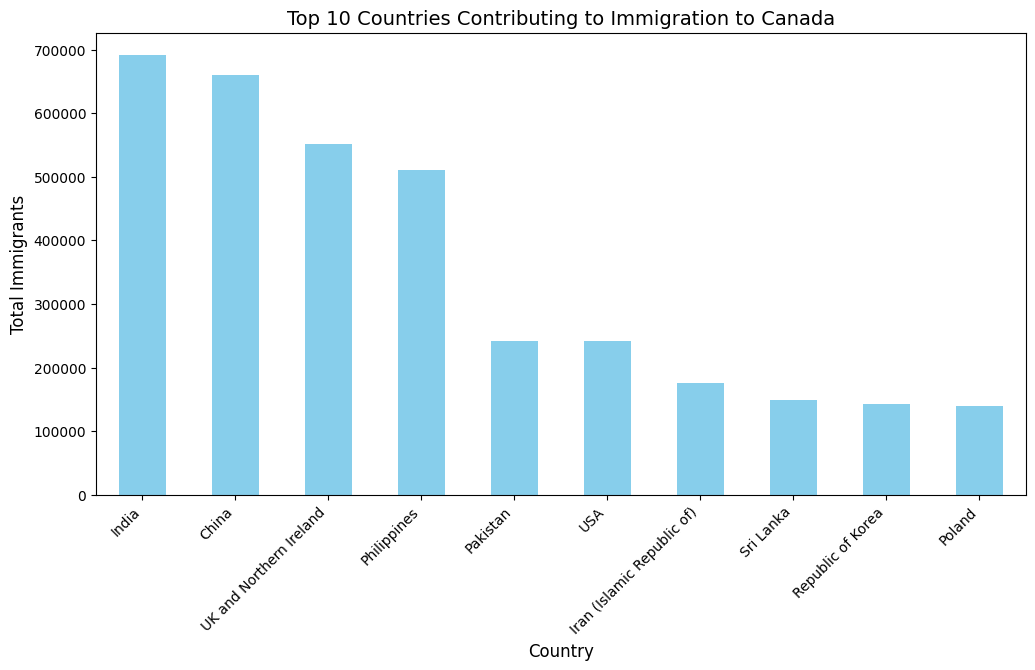

In [31]:
# Sum immigration for each country across all years
country_immigration = df.groupby('Country')[year_columns].sum().sum(axis=1)

# Get the top 10 countries by total immigration
top_10_countries = country_immigration.nlargest(10)

# Plotting
plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar', color='skyblue')

# Formatting
plt.title('Top 10 Countries Contributing to Immigration to Canada', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Immigrants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


###Total Immigration: Developed vs. Developing Regions

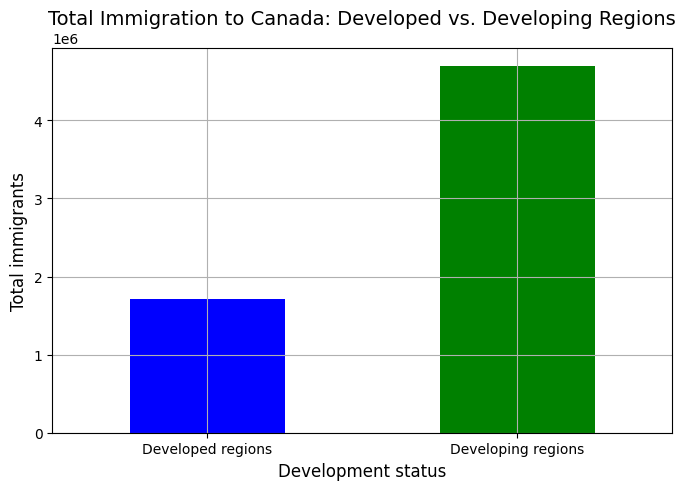

In [37]:
dev_immigration = df.groupby('DevName')[year_columns].sum().sum(axis = 1)

plt.figure(figsize = (8,5))
dev_immigration.plot(kind = 'bar', color = ['blue', 'green'])

plt.title('Total Immigration to Canada: Developed vs. Developing Regions', fontsize = 14)
plt.xlabel('Development status', fontsize = 12)
plt.ylabel('Total immigrants', fontsize = 12)
plt.xticks(rotation = 0)
plt.grid(True)
plt.show()


###Yearly Immigration Trends for Developed vs. Developing

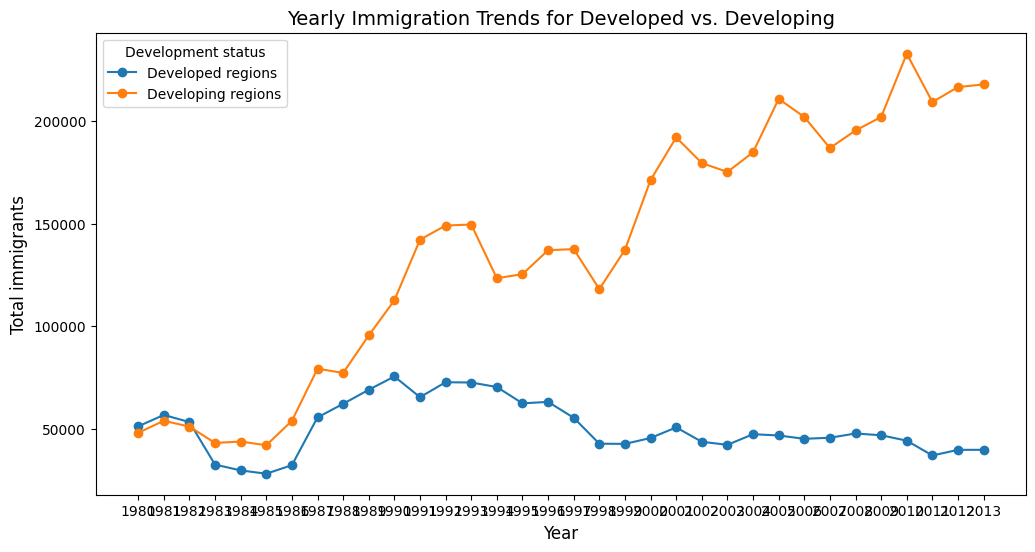

In [38]:
dev_trends = df.groupby('DevName')[year_columns].sum().T

plt.figure(figsize = (12,6))
for category in dev_trends.columns:
  plt.plot(dev_trends.index, dev_trends[category], marker = 'o', label = category)
  plt.title('Yearly Immigration Trends for Developed vs. Developing', fontsize = 14)
  plt.xlabel('Year', fontsize = 12)
  plt.ylabel('Total immigrants', fontsize = 12)
  plt.legend(title = 'Development status')

###How Immigration from Each Group Contributes Over Time

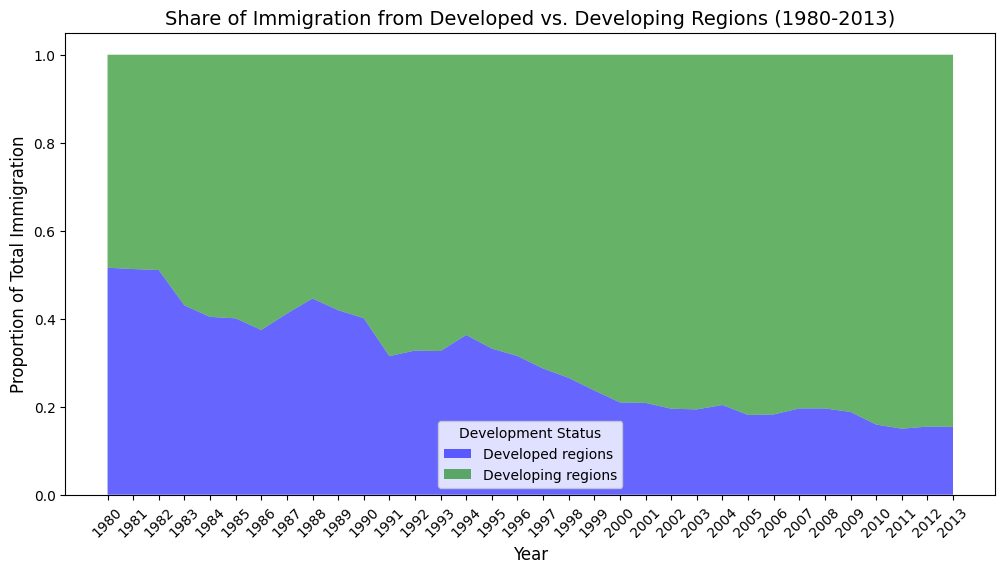

In [41]:
# Normalize to show percentage share
dev_trends_pct = dev_trends.div(dev_trends.sum(axis=1), axis=0)

# Plot stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(dev_trends_pct.index, dev_trends_pct.T, labels=dev_trends_pct.columns, colors=['blue', 'green'], alpha=0.6)

# Formatting
plt.title('Share of Immigration from Developed vs. Developing Regions (1980-2013)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation = 45)
plt.ylabel('Proportion of Total Immigration', fontsize=12)
plt.legend(title='Development Status')
plt.show()


###Year-over-Year Percentage Change

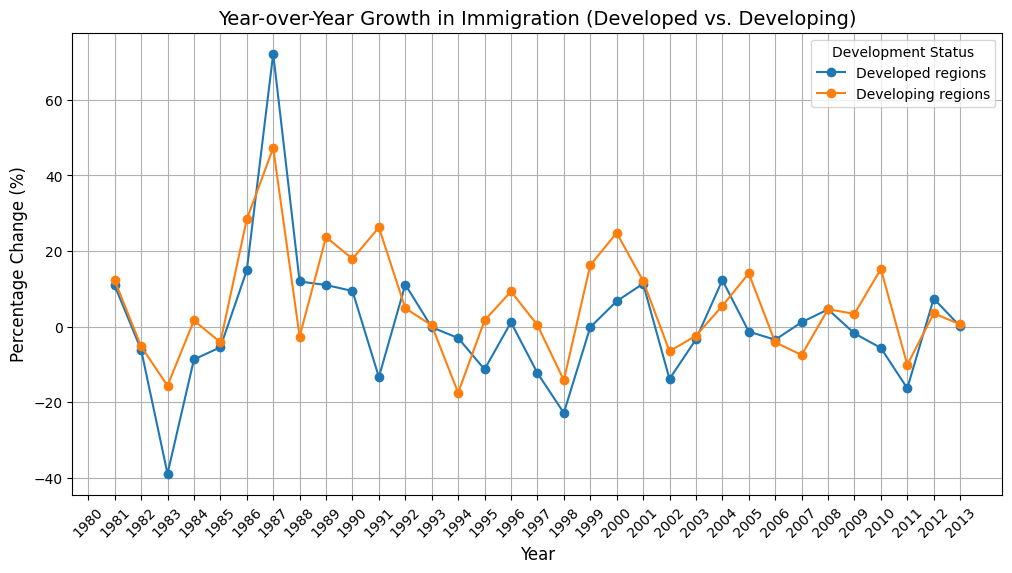

In [42]:
# Compute yearly percentage change
dev_growth = dev_trends.pct_change() * 100

# Plot percentage change
plt.figure(figsize=(12, 6))
for category in dev_growth.columns:
    plt.plot(dev_growth.index, dev_growth[category], marker='o', linestyle='-', label=category)

# Formatting
plt.title('Year-over-Year Growth in Immigration (Developed vs. Developing)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.legend(title='Development Status')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


###Plot total immigration over years

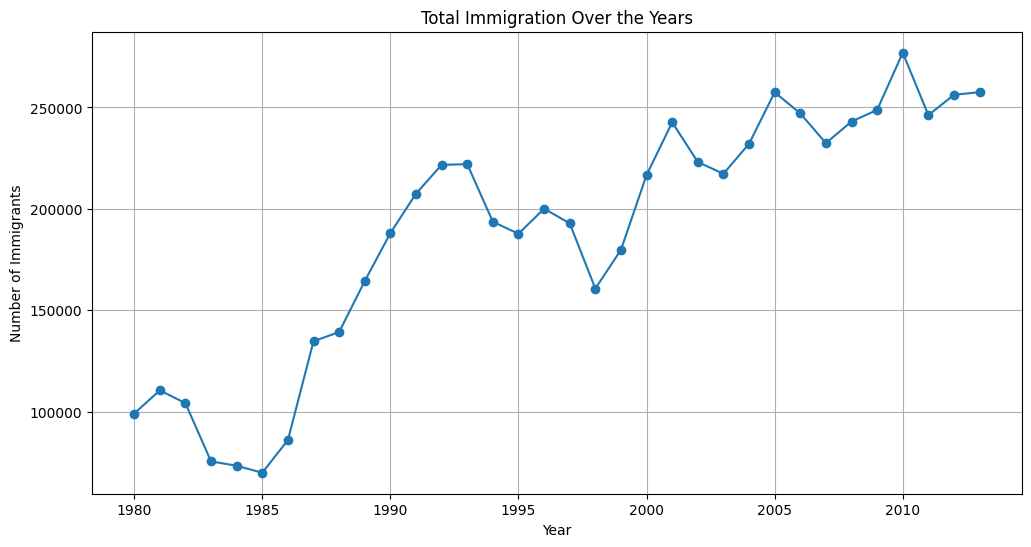

In [44]:
# Plot total immigration over years
df[year_columns].sum().plot(figsize=(12,6), marker='o')
plt.title('Total Immigration Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.grid(True)
plt.show()